# 11 — Invisibilidade à Média e Matched Pairs Intracluster

**Objetivo:** formalizar o conceito de *invisibilidade à média* — municípios que, dentro do
mesmo cluster, apresentam desfecho operacional sistematicamente divergente de seus vizinhos
contextuais — e identificar pares de municípios "gêmeos" em contexto socioeconômico mas
divergentes em qualidade de serviço.

**Contribuição científica:**
Este notebook implementa os dois conceitos centrais do paper de journal subsequente à série SBrT 2025–2026:
1. **Índice de Invisibilidade à Média (IV)** — métrica individual que quantifica o quanto
   cada município diverge do centróide do seu cluster nas dimensões operacionais, ponderada
   pelos pesos SHAP do cluster.
2. **Matched Pairs Intracluster** — pares de municípios com contexto socioeconômico similar
   (vizinhos no espaço de features estruturais) mas desfechos operacionais divergentes
   (distantes no espaço RQUAL), revelando heterogeneidade oculta dentro de cada perfil.

| Seção | Conteúdo |
|---|---|
| 1. Índice IV | Cálculo, distribuição e ranqueamento por cluster |
| 2. Matched Pairs | Identificação e análise dos pares gêmeos divergentes |
| 3. Análise SHAP dos pares | O que explica a divergência dentro do par |
| 4. Casos ilustrativos | 2–3 pares concretos por cluster com narrativa regulatória |
| 5. Exportação | CSVs de IV e pares para uso no paper |

**Entradas:**
- `rqual_2022_clusterizado.csv`
- `shap_importancia_por_cluster.csv`
- `shap_explicacoes_municipios.csv`
- `municipios_excepcionais_lof.csv`

**Saídas:**
- `iv_invisibilidade_municipios.csv` — IV de todos os 5.570 municípios
- `matched_pairs_intracluster.csv` — pares gêmeos divergentes com score de divergência
- figuras: distribuição IV, mapa de pares, análise dos pares


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuração visual padrão do projeto
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

CLUSTER_NAMES = {
    0: 'C0: Urbano-Avançado',
    1: 'C1: Intermediário',
    2: 'C2: Nordeste Vulnerável',
    3: 'C3: Norte/Amazônico',
    4: 'C4: Capitais'
}
CLUSTER_COLORS = {0: '#4878CF', 1: '#6ACC65', 2: '#D65F5F', 3: '#B47CC7', 4: '#C4AD66'}

print('Imports OK')


Imports OK


In [2]:
# Caminhos relativos (executar a partir de 3-KMeans+HDBSCAN/)
BASE_PATH = 'rqual_2022_clusterizado.csv'
SHAP_IMP_PATH = 'shap_importancia_por_cluster.csv'
SHAP_MUN_PATH = 'shap_explicacoes_municipios.csv'
LOF_PATH = 'municipios_excepcionais_lof.csv'

base = pd.read_csv(BASE_PATH)
shap_imp = pd.read_csv(SHAP_IMP_PATH, index_col=0)
shap_mun = pd.read_csv(SHAP_MUN_PATH)
lof_out  = pd.read_csv(LOF_PATH)

# Renomear colunas longas para conveniência
rename_map = {
    'Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)': 'pib_agropecuaria',
    'Valor adicionado bruto da Indústria,\na preços correntes\n(R$ 1.000)': 'pib_industria',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita',
    'POP__Área da unidade territorial (Quilômetros quadrados)': 'area_km2',
    'POP__Densidade demográfica (Habitante por quilômetro quadrado)': 'densidade',
    'LAT__lat': 'lat',
    'LAT__lon': 'lon',
    'URB__Rural': 'pop_rural',
    'IDHM__IDHM 2010': 'idhm',
}
base = base.rename(columns=rename_map)

RQUAL_COLS  = ['IND2', 'IND4', 'IND5', 'IND8', 'IND9', 'INF1', 'INF4-UP']
SOCIO_COLS  = ['pib_agropecuaria', 'pib_industria', 'pib_per_capita',
               'area_km2', 'densidade', 'pop_rural', 'idhm']
GEO_COLS    = ['lat', 'lon']

print(f'Base: {base.shape[0]:,} municípios × {base.shape[1]} colunas')
print(f'Ausentes RQUAL: {base[RQUAL_COLS].isnull().sum().sum()}')
print(f'Ausentes SOCIO: {base[SOCIO_COLS].isnull().sum().sum()}')
print()
print('Distribuição por cluster:')
print(base['kmeans_cluster'].value_counts().sort_index()
      .rename(index=CLUSTER_NAMES).to_string())


Base: 5,570 municípios × 26 colunas
Ausentes RQUAL: 0
Ausentes SOCIO: 0

Distribuição por cluster:
kmeans_cluster
C0: Urbano-Avançado         216
C1: Intermediário          3054
C2: Nordeste Vulnerável    2057
C3: Norte/Amazônico         216
C4: Capitais                 27


## 1. Índice de Invisibilidade à Média (IV)

O índice IV quantifica o quanto cada município diverge do centróide do seu cluster nas
dimensões operacionais (RQUAL), ponderando cada indicador pelo peso SHAP do cluster.

**Formulação:**

$$\text{IV}_i = \sum_j w_{cj} \cdot |z_{ij} - \bar{z}_{cj}|$$

onde:
- $z_{ij}$ = z-score padronizado do indicador $j$ para o município $i$
- $\bar{z}_{cj}$ = média do cluster $c$ no indicador $j$ (centróide)
- $w_{cj}$ = peso SHAP normalizado do indicador $j$ no cluster $c$

Municípios com IV alto são os que mais divergem da média do cluster nas dimensões que
o próprio modelo considera mais determinantes — ou seja, são os mais *invisíveis* a
uma análise baseada apenas no perfil médio.


In [3]:
# ── Padronização z-score global (mesma escala para todos os clusters) ──────
scaler = RobustScaler()
base_z = base.copy()
base_z[RQUAL_COLS] = scaler.fit_transform(base[RQUAL_COLS].fillna(base[RQUAL_COLS].median()))

# ── Pesos SHAP por cluster (apenas indicadores RQUAL) ────────────────────────
# shap_imp tem índice = features, colunas = clusters
# Normalizar para soma = 1 dentro de cada cluster (apenas RQUAL)
shap_rqual = shap_imp.loc[RQUAL_COLS].copy()
shap_weights = shap_rqual.div(shap_rqual.sum(axis=0), axis=1)  # normaliza por coluna

# Mapear nomes de coluna do shap_imp para cluster id
cluster_col_map = {col: int(col.split(':')[0].replace('C','')) for col in shap_weights.columns}

# ── Cálculo do IV por município ───────────────────────────────────────────────
iv_records = []

for cluster_id, cluster_name in CLUSTER_NAMES.items():
    sub = base_z[base_z['kmeans_cluster'] == cluster_id].copy()
    col_name = [c for c in shap_weights.columns if c.startswith(f'C{cluster_id}:')][0]
    weights = shap_weights[col_name]  # Series indexada por feature

    # Centróide do cluster nos indicadores RQUAL
    centroid = sub[RQUAL_COLS].mean()

    # Desvio ponderado de cada município ao centróide
    for _, row in sub.iterrows():
        desvio = (row[RQUAL_COLS] - centroid).abs()
        iv = (desvio * weights).sum()
        iv_records.append({
            'cod_mun': row['cod_mun'],
            'nome_mun': row['nome_mun_rqual'],
            'uf': row['uf_rqual'],
            'kmeans_cluster': cluster_id,
            'cluster_nome': cluster_name,
            'iv_score': iv,
            **{f'desvio_{c}': float((row[c] - centroid[c]) * weights[c]) for c in RQUAL_COLS}
        })

iv_df = pd.DataFrame(iv_records).sort_values('iv_score', ascending=False).reset_index(drop=True)
iv_df['iv_rank_global'] = iv_df['iv_score'].rank(ascending=False, method='min').astype(int)
iv_df['iv_rank_cluster'] = iv_df.groupby('kmeans_cluster')['iv_score'].rank(
    ascending=False, method='min').astype(int)

print(f'IV calculado para {len(iv_df):,} municípios')
print()
print('Estatísticas do IV por cluster:')
print(iv_df.groupby('cluster_nome')['iv_score']
      .agg(['mean','median','std','max'])
      .round(4).to_string())


IV calculado para 5,570 municípios

Estatísticas do IV por cluster:
                           mean  median     std     max
cluster_nome                                           
C0: Urbano-Avançado      0.3483  0.2806  0.2162  1.4539
C1: Intermediário        0.5586  0.4638  0.3471  3.6262
C2: Nordeste Vulnerável  0.8103  0.7623  0.4156  3.3749
C3: Norte/Amazônico      1.3604  1.3251  0.6448  2.7866
C4: Capitais             0.2229  0.2098  0.0842  0.4710


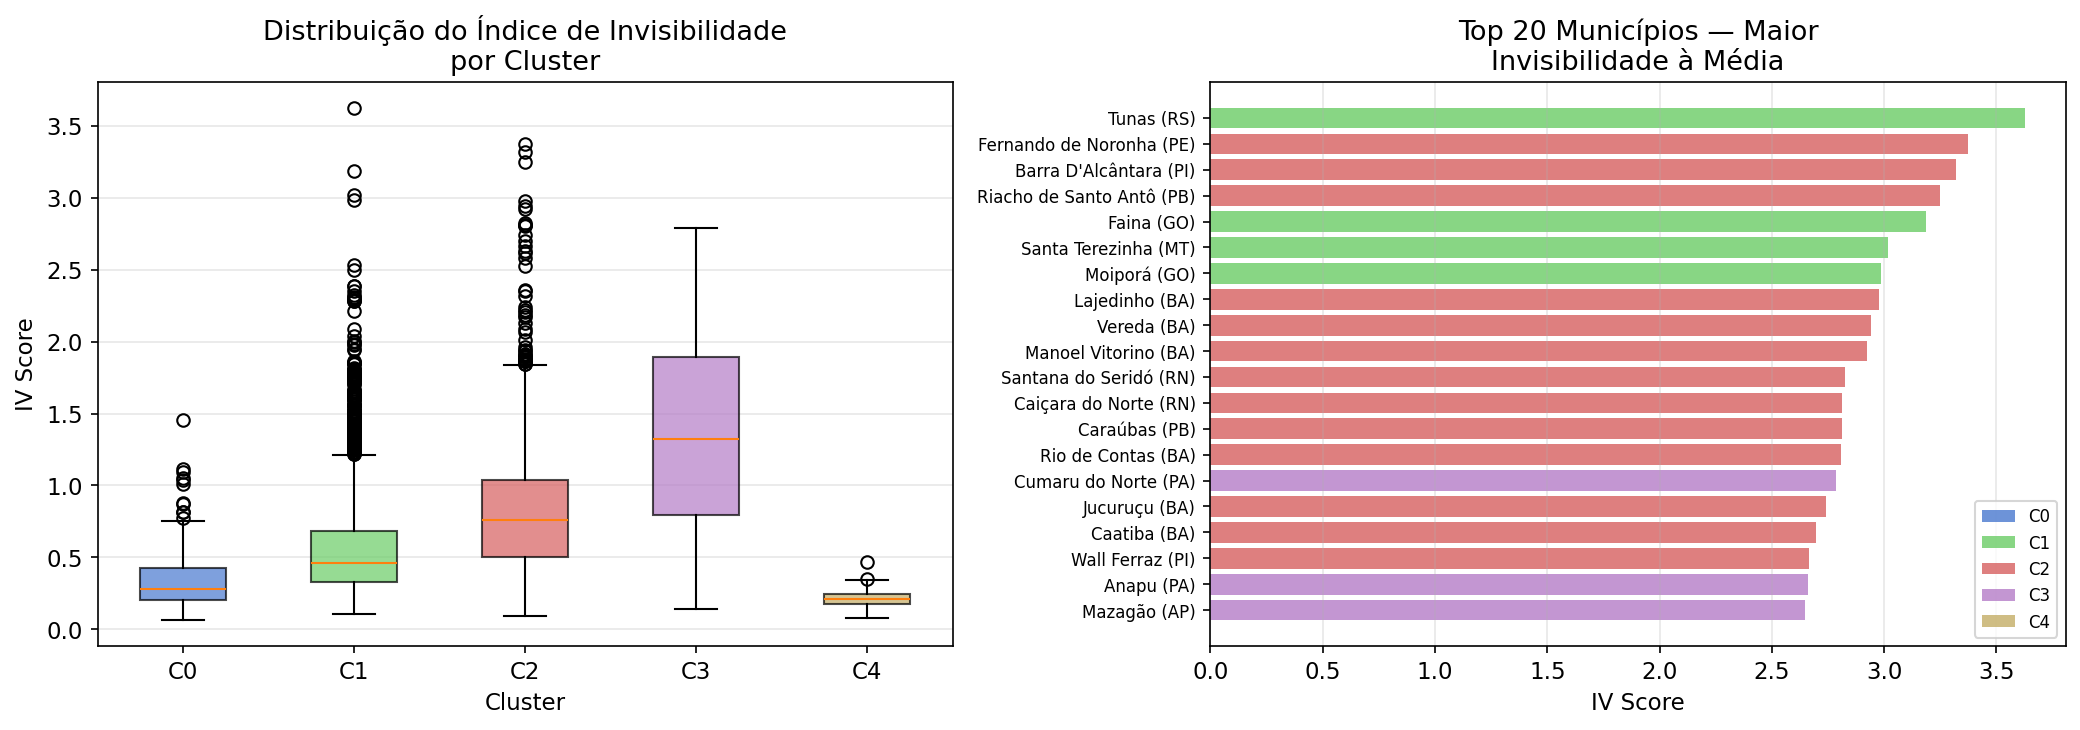

Figura salva: fig_iv_distribuicao.png


In [4]:
# ── Figura: distribuição do IV por cluster ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
order = [CLUSTER_NAMES[i] for i in [0,1,2,3,4]]
data_box = [iv_df[iv_df['cluster_nome'] == cn]['iv_score'].values for cn in order]
bp = ax.boxplot(data_box, patch_artist=True, notch=False, vert=True)
for patch, cid in zip(bp['boxes'], [0,1,2,3,4]):
    patch.set_facecolor(CLUSTER_COLORS[cid])
    patch.set_alpha(0.7)
ax.set_xticklabels([cn.split(':')[0] for cn in order])
ax.set_xlabel('Cluster')
ax.set_ylabel('IV Score')
ax.set_title('Distribuição do Índice de Invisibilidade\npor Cluster')
ax.grid(axis='y', alpha=0.3)

# Top-20 municípios com maior IV
ax2 = axes[1]
top20 = iv_df.head(20)
colors_top = [CLUSTER_COLORS[c] for c in top20['kmeans_cluster']]
bars = ax2.barh(range(len(top20)), top20['iv_score'], color=colors_top, alpha=0.8)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels([f"{r['nome_mun'][:20]} ({r['uf']})" for _, r in top20.iterrows()],
                     fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('IV Score')
ax2.set_title('Top 20 Municípios — Maior\nInvisibilidade à Média')
ax2.grid(axis='x', alpha=0.3)

# Legenda de cluster
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=CLUSTER_COLORS[i], alpha=0.8,
                         label=CLUSTER_NAMES[i].split(':')[0])
                   for i in range(5)]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_iv_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_iv_distribuicao.png')


## 2. Matched Pairs Intracluster

Identificação de pares de municípios dentro do mesmo cluster que são:
- **Contexto similar:** próximos no espaço de features socioeconômicas e geográficas
  (os fatores que deveriam predizer contexto territorial comparável)
- **Desfecho divergente:** distantes no espaço de indicadores RQUAL operacionais

**Critérios:**
- Distância socioeconômica ≤ percentil 10 intracluster (vizinhos mais próximos em contexto)
- Distância RQUAL ≥ percentil 75 intracluster (desfechos mais divergentes)
- Par não redundante: para cada município, manter apenas o parceiro mais divergente

Esses pares são os candidatos a "municípios invisíveis à média" com maior valor
regulatório: contexto não explica desfecho.


In [5]:
# ── Matched Pairs Intracluster ───────────────────────────────────────────────
scaler_socio = RobustScaler()
scaler_rqual = RobustScaler()

pairs_all = []
summary = {}

for cluster_id in [0, 1, 2, 3]:  # C4 tem apenas 27 municípios, pula
    sub = base[base['kmeans_cluster'] == cluster_id].copy().reset_index(drop=True)
    n = len(sub)

    X_socio = scaler_socio.fit_transform(
        sub[SOCIO_COLS + GEO_COLS].fillna(sub[SOCIO_COLS + GEO_COLS].median()))
    X_rqual = scaler_rqual.fit_transform(
        sub[RQUAL_COLS].fillna(sub[RQUAL_COLS].median()))

    D_socio = euclidean_distances(X_socio)
    D_rqual = euclidean_distances(X_rqual)
    np.fill_diagonal(D_socio, np.inf)
    np.fill_diagonal(D_rqual, 0.0)

    thresh_socio = np.percentile(D_socio[D_socio < np.inf], 10)
    thresh_rqual = np.percentile(D_rqual[D_rqual > 0], 75)

    rows_idx, cols_idx = np.where((D_socio <= thresh_socio) & (D_rqual >= thresh_rqual))
    candidate_pairs = {tuple(sorted([i, j])) for i, j in zip(rows_idx, cols_idx) if i != j}

    # Para cada município, manter apenas o par mais divergente
    best_pair = {}
    for i, j in candidate_pairs:
        for mun, partner in [(i, j), (j, i)]:
            if mun not in best_pair or D_rqual[mun, partner] > D_rqual[mun, best_pair[mun]]:
                best_pair[mun] = partner

    seen = set()
    for mun, partner in best_pair.items():
        key = tuple(sorted([mun, partner]))
        if key not in seen:
            seen.add(key)
            i, j = key
            r_i = sub.iloc[i]
            r_j = sub.iloc[j]
            rec = {
                'cluster_id': cluster_id,
                'cluster_nome': CLUSTER_NAMES[cluster_id],
                'cod_mun_a': r_i['cod_mun'], 'nome_a': r_i['nome_mun_rqual'], 'uf_a': r_i['uf_rqual'],
                'cod_mun_b': r_j['cod_mun'], 'nome_b': r_j['nome_mun_rqual'], 'uf_b': r_j['uf_rqual'],
                'dist_socio': float(D_socio[i, j]),
                'dist_rqual': float(D_rqual[i, j]),
                'divergencia': float(D_rqual[i, j] / (D_socio[i, j] + 1e-9)),
            }
            for c in RQUAL_COLS:
                rec[f'{c}_a'] = float(r_i[c]) if pd.notna(r_i[c]) else 0.0
                rec[f'{c}_b'] = float(r_j[c]) if pd.notna(r_j[c]) else 0.0
            for s in SOCIO_COLS:
                rec[f'{s}_a'] = float(r_i[s]) if pd.notna(r_i[s]) else 0.0
                rec[f'{s}_b'] = float(r_j[s]) if pd.notna(r_j[s]) else 0.0
            pairs_all.append(rec)

    summary[CLUSTER_NAMES[cluster_id]] = len(seen)
    print(f'{CLUSTER_NAMES[cluster_id]} (n={n}): {len(seen):,} pares únicos identificados')

pairs_df = (pd.DataFrame(pairs_all)
              .sort_values('divergencia', ascending=False)
              .reset_index(drop=True))
pairs_df['pair_rank_global'] = range(1, len(pairs_df) + 1)

print(f'\nTotal de pares: {len(pairs_df):,}')
print('Score de divergência — top 5:')
print(pairs_df[['nome_a','uf_a','nome_b','uf_b','cluster_nome','divergencia']].head(5).to_string(index=False))


C0: Urbano-Avançado (n=216): 90 pares únicos identificados


C1: Intermediário (n=3054): 2,319 pares únicos identificados


C2: Nordeste Vulnerável (n=2057): 1,485 pares únicos identificados
C3: Norte/Amazônico (n=216): 139 pares únicos identificados

Total de pares: 4,033
Score de divergência — top 5:
           nome_a uf_a                nome_b uf_b            cluster_nome  divergencia
          Ibarama   RS                 Tunas   RS       C1: Intermediário    47.813842
           Marema   SC Santo Expedito do Sul   RS       C1: Intermediário    28.052128
   Gramado Xavier   RS                 Tunas   RS       C1: Intermediário    27.692551
Santana do Seridó   RN              Coxixola   PB C2: Nordeste Vulnerável    24.451987
 Fortuna de Minas   MG                 Pequi   MG       C1: Intermediário    22.670438


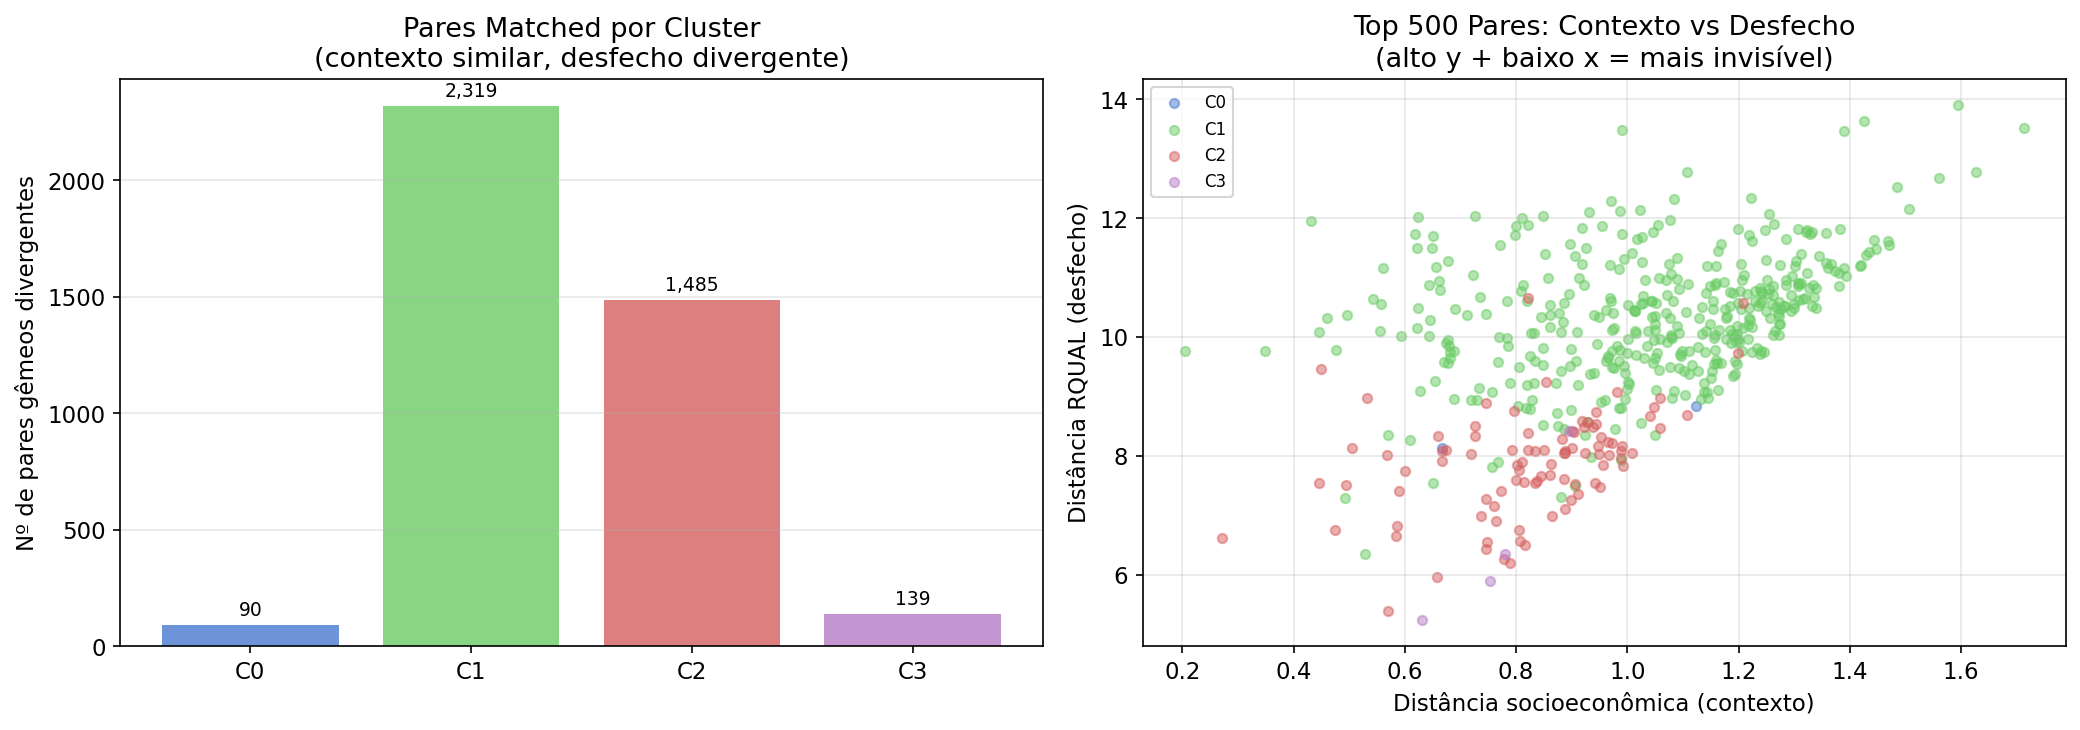

Figura salva: fig_matched_pairs_distribuicao.png


In [6]:
# ── Figura: distribuição de pares e score de divergência ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: total de pares por cluster
ax = axes[0]
cluster_order = [c for c in CLUSTER_NAMES.values() if c in summary]
counts = [summary[c] for c in cluster_order]
colors_bar = [CLUSTER_COLORS[int(c.split(':')[0].replace('C',''))] for c in cluster_order]
bars = ax.bar(range(len(cluster_order)), counts, color=colors_bar, alpha=0.8)
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels([c.split(':')[0] for c in cluster_order])
ax.set_ylabel('Nº de pares gêmeos divergentes')
ax.set_title('Pares Matched por Cluster\n(contexto similar, desfecho divergente)')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Scatter: dist_socio vs dist_rqual (top 500 pares para visualização)
ax2 = axes[1]
top_pairs = pairs_df.head(500)
for cid, cn in CLUSTER_NAMES.items():
    mask = top_pairs['cluster_id'] == cid
    if mask.sum() > 0:
        ax2.scatter(top_pairs[mask]['dist_socio'], top_pairs[mask]['dist_rqual'],
                   c=CLUSTER_COLORS[cid], alpha=0.5, s=20, label=cn.split(':')[0])
ax2.set_xlabel('Distância socioeconômica (contexto)')
ax2.set_ylabel('Distância RQUAL (desfecho)')
ax2.set_title('Top 500 Pares: Contexto vs Desfecho\n(alto y + baixo x = mais invisível)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_matched_pairs_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_matched_pairs_distribuicao.png')


## 3. Análise SHAP dos Pares Divergentes

Para cada par identificado, qual indicador RQUAL mais explica a divergência?

Esta seção identifica o **indicador de maior divergência absoluta** em cada par,
cruzando com os pesos SHAP do cluster para determinar se essa divergência ocorre
em dimensões que o modelo considera explicativas ou residuais.


In [7]:
# ── Indicador dominante da divergência em cada par ───────────────────────────
shap_rqual = shap_imp.loc[[f for f in RQUAL_COLS if f in shap_imp.index]].copy()
shap_weights = shap_rqual.div(shap_rqual.sum(axis=0), axis=1)

dominance_records = []
for _, pair in pairs_df.iterrows():
    cid = int(pair['cluster_id'])
    col_name = [c for c in shap_weights.columns if c.startswith(f'C{cid}:')][0]
    w = shap_weights[col_name]

    divergencias = {}
    for c in RQUAL_COLS:
        if c in w.index:
            div_raw  = abs(pair[f'{c}_a'] - pair[f'{c}_b'])
            div_weighted = div_raw * float(w[c])
            divergencias[c] = div_weighted

    if divergencias:
        ind_dominante = max(divergencias, key=divergencias.get)
        dominance_records.append({
            'pair_rank_global': int(pair['pair_rank_global']),
            'cluster_id': cid,
            'indicador_dominante': ind_dominante,
            'divergencia_ponderada': divergencias[ind_dominante],
            'divergencia_total': sum(divergencias.values()),
        })

dom_df = pd.DataFrame(dominance_records)
pairs_df = pairs_df.merge(dom_df[['pair_rank_global','indicador_dominante',
                                   'divergencia_ponderada','divergencia_total']],
                          on='pair_rank_global', how='left')

print('Indicador dominante mais frequente por cluster:')
print(pairs_df.groupby(['cluster_nome','indicador_dominante'])
      .size().reset_index(name='count')
      .sort_values(['cluster_nome','count'], ascending=[True,False])
      .groupby('cluster_nome').head(3).to_string(index=False))


Indicador dominante mais frequente por cluster:
           cluster_nome indicador_dominante  count
    C0: Urbano-Avançado             INF4-UP     72
    C0: Urbano-Avançado                IND4     10
    C0: Urbano-Avançado                IND5      5
      C1: Intermediário                IND5   1842
      C1: Intermediário             INF4-UP    196
      C1: Intermediário                IND4     96
C2: Nordeste Vulnerável                IND5   1131
C2: Nordeste Vulnerável                IND8    111
C2: Nordeste Vulnerável                IND4    103
    C3: Norte/Amazônico                IND5    112
    C3: Norte/Amazônico                IND4     20
    C3: Norte/Amazônico                IND8      7


## 4. Casos Ilustrativos

Seleção dos 3 pares mais divergentes por cluster com narrativa regulatória.
Esses casos serão usados como exemplos concretos no paper de journal.


In [8]:
# ── Top-3 pares por cluster — tabela de casos ────────────────────────────────
print('=' * 90)
for cid in [0, 1, 2, 3]:
    top3 = pairs_df[pairs_df['cluster_id'] == cid].head(3)
    print(f'\n{CLUSTER_NAMES[cid]} — Top 3 pares mais divergentes')
    print('-' * 90)
    for _, p in top3.iterrows():
        print(f'  Par: {p["nome_a"]} ({p["uf_a"]}) ↔ {p["nome_b"]} ({p["uf_b"]})')
        print(f'       Divergência: {p["divergencia"]:.3f} | '
              f'Dist.socio: {p["dist_socio"]:.3f} | '
              f'Dist.RQUAL: {p["dist_rqual"]:.3f} | '
              f'Indicador dominante: {p["indicador_dominante"]}')
        # Mostrar valores dos indicadores mais divergentes
        diffs = {c: abs(p[f'{c}_a'] - p[f'{c}_b']) for c in RQUAL_COLS}
        top2_ind = sorted(diffs, key=diffs.get, reverse=True)[:2]
        for ind in top2_ind:
            print(f'         {ind}: {p[f"{ind}_a"]:.3f} vs {p[f"{ind}_b"]:.3f} '
                  f'(Δ={diffs[ind]:.3f})')
    print()



C0: Urbano-Avançado — Top 3 pares mais divergentes
------------------------------------------------------------------------------------------
  Par: Catas Altas (MG) ↔ Itatiaiuçu (MG)
       Divergência: 12.185 | Dist.socio: 0.667 | Dist.RQUAL: 8.124 | Indicador dominante: INF4-UP
         IND2: -0.179 vs 1.762 (Δ=1.941)
         INF4-UP: 0.814 vs -0.767 (Δ=1.581)
  Par: Itatiaiuçu (MG) ↔ Saquarema (RJ)
       Divergência: 7.861 | Dist.socio: 1.123 | Dist.RQUAL: 8.828 | Indicador dominante: IND5
         IND2: 1.762 vs -0.423 (Δ=2.186)
         IND8: -0.394 vs -1.679 (Δ=1.285)
  Par: Itatiaiuçu (MG) ↔ Marataízes (ES)
       Divergência: 6.239 | Dist.socio: 1.604 | Dist.RQUAL: 10.004 | Indicador dominante: INF4-UP
         IND2: 1.762 vs -0.695 (Δ=2.457)
         IND4: -1.135 vs 0.528 (Δ=1.663)


C1: Intermediário — Top 3 pares mais divergentes
------------------------------------------------------------------------------------------
  Par: Ibarama (RS) ↔ Tunas (RS)
       Divergência:

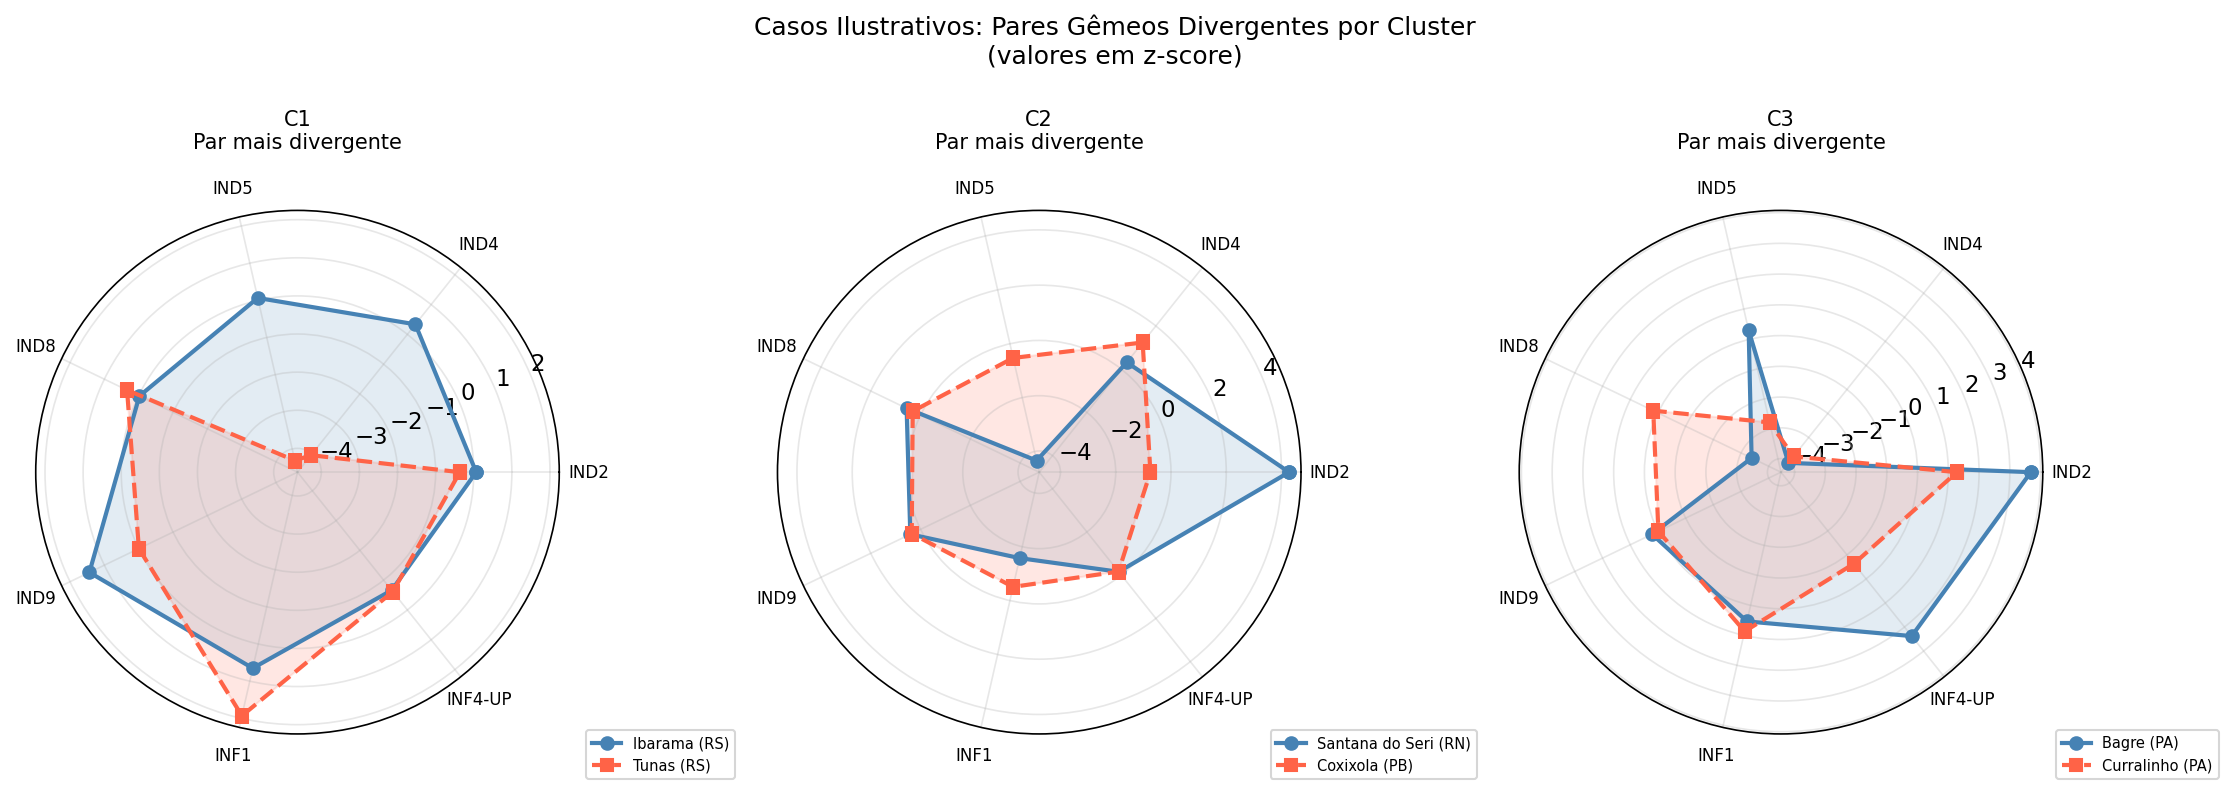

Figura salva: fig_casos_ilustrativos_radar.png


In [9]:
# ── Figura: radar dos top-1 par por cluster ──────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

# Selecionar top-1 par de C1, C2, C3 (mais interessantes narrativamente)
selected_clusters = [1, 2, 3]
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

angles = np.linspace(0, 2 * np.pi, len(RQUAL_COLS), endpoint=False).tolist()
angles += angles[:1]

for idx, cid in enumerate(selected_clusters):
    top_pair = pairs_df[pairs_df['cluster_id'] == cid].iloc[0]
    ax = fig.add_subplot(gs[idx], polar=True)

    vals_a = [top_pair[f'{c}_a'] for c in RQUAL_COLS] + [top_pair[f'{RQUAL_COLS[0]}_a']]
    vals_b = [top_pair[f'{c}_b'] for c in RQUAL_COLS] + [top_pair[f'{RQUAL_COLS[0]}_b']]

    ax.plot(angles, vals_a, 'o-', linewidth=2, color='steelblue', label=f'{top_pair["nome_a"][:15]} ({top_pair["uf_a"]})')
    ax.fill(angles, vals_a, alpha=0.15, color='steelblue')
    ax.plot(angles, vals_b, 's--', linewidth=2, color='tomato', label=f'{top_pair["nome_b"][:15]} ({top_pair["uf_b"]})')
    ax.fill(angles, vals_b, alpha=0.15, color='tomato')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RQUAL_COLS, fontsize=8)
    ax.set_title(f'{CLUSTER_NAMES[cid].split(":")[0]}\nPar mais divergente', fontsize=10, pad=15)
    ax.legend(loc='lower right', fontsize=7, bbox_to_anchor=(1.35, -0.1))
    ax.grid(alpha=0.3)

plt.suptitle('Casos Ilustrativos: Pares Gêmeos Divergentes por Cluster\n(valores em z-score)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_casos_ilustrativos_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_casos_ilustrativos_radar.png')


## 5. Exportação de Artefatos

In [10]:
# ── Exportar IV de todos os municípios ───────────────────────────────────────
iv_export = iv_df[[
    'cod_mun', 'nome_mun', 'uf', 'kmeans_cluster', 'cluster_nome',
    'iv_score', 'iv_rank_global', 'iv_rank_cluster'
] + [f'desvio_{c}' for c in RQUAL_COLS]]

iv_export.to_csv('iv_invisibilidade_municipios.csv', index=False)
print(f'Exportado: iv_invisibilidade_municipios.csv ({len(iv_export):,} linhas)')

# ── Exportar pares matched ────────────────────────────────────────────────────
pairs_export = pairs_df[[
    'pair_rank_global', 'cluster_id', 'cluster_nome',
    'cod_mun_a', 'nome_a', 'uf_a',
    'cod_mun_b', 'nome_b', 'uf_b',
    'dist_socio', 'dist_rqual', 'divergencia',
    'indicador_dominante', 'divergencia_ponderada',
] + [f'{c}_a' for c in RQUAL_COLS] + [f'{c}_b' for c in RQUAL_COLS]]

pairs_export.to_csv('matched_pairs_intracluster.csv', index=False)
print(f'Exportado: matched_pairs_intracluster.csv ({len(pairs_export):,} pares)')

# ── Resumo final ──────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('RESUMO — NB11 Invisibilidade à Média e Matched Pairs')
print('=' * 60)
print(f'  Municípios com IV calculado: {len(iv_df):,}')
print(f'  IV mediano global: {iv_df["iv_score"].median():.4f}')
print(f'  IV máximo: {iv_df["iv_score"].max():.4f} ({iv_df.iloc[0]["nome_mun"]}/{iv_df.iloc[0]["uf"]})')
print()
print(f'  Pares matched identificados: {len(pairs_df):,}')
for cid in [0,1,2,3]:
    n = (pairs_df['cluster_id']==cid).sum()
    print(f'    {CLUSTER_NAMES[cid]}: {n:,} pares')
print()
print('Artefatos gerados:')
print('  iv_invisibilidade_municipios.csv')
print('  matched_pairs_intracluster.csv')
print('  fig_iv_distribuicao.png')
print('  fig_matched_pairs_distribuicao.png')
print('  fig_casos_ilustrativos_radar.png')


Exportado: iv_invisibilidade_municipios.csv (5,570 linhas)


Exportado: matched_pairs_intracluster.csv (4,033 pares)

RESUMO — NB11 Invisibilidade à Média e Matched Pairs
  Municípios com IV calculado: 5,570
  IV mediano global: 0.5573
  IV máximo: 3.6262 (Tunas/RS)

  Pares matched identificados: 4,033
    C0: Urbano-Avançado: 90 pares
    C1: Intermediário: 2,319 pares
    C2: Nordeste Vulnerável: 1,485 pares
    C3: Norte/Amazônico: 139 pares

Artefatos gerados:
  iv_invisibilidade_municipios.csv
  matched_pairs_intracluster.csv
  fig_iv_distribuicao.png
  fig_matched_pairs_distribuicao.png
  fig_casos_ilustrativos_radar.png
